# Análisis exploratorio - Microproyecto - Diabetes Risk

<b> Integrantes: </b>

* Jared Foster Orduz
* Jeferson David Vargas Toca
* Andres Felipe Florez Garces
* Oscar Enrique Morillo

## 0. Imports

A continuación se realizan los imports necesarios para el análisis exploratorio de los datos.  Se debe tener en cuenta que se debe activar el ambiente del proyecto que se llama "venv":

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Lectura de los datos

Se lee el archivo csv que contiene los datos que se van a utilizar en este proyecto y por ende en esta exploración:

In [2]:
ruta_csv = '../data/diabetes_binary_health_indicators_BRFSS2015.csv'

In [3]:
df_datos = pd.read_csv(ruta_csv)
df_datos.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Como no se logra observar bien, se imprimen los nombres de las columnas:

In [4]:
print("Número de columnas:", len(df_datos.columns))
df_datos.columns

Número de columnas: 22


Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

Vemos el tipo de dato que es cada una de las variables:

In [5]:
df_datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

Se observa entonces que son 253,680 datos que no son nulos y que todas las variables son de tipo float64, pero quizá hayan variables categóricas escondidas como float64.

A continuación, se muestran las estadísticas de cada una de las variables.

In [6]:
df_datos.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


## 2. Análisis de cada una de las variables

A continuación se va a realizar el análisis de cada una de las variables:

### 2.1. Variable a predecir: Diabetes_binary

Es la variable que se busca predecir, es nuestra "y", si es 0 significa que el paciente no tiene diabetes, si es 1 significa que el paciente tiene prediabetes o diabetes.

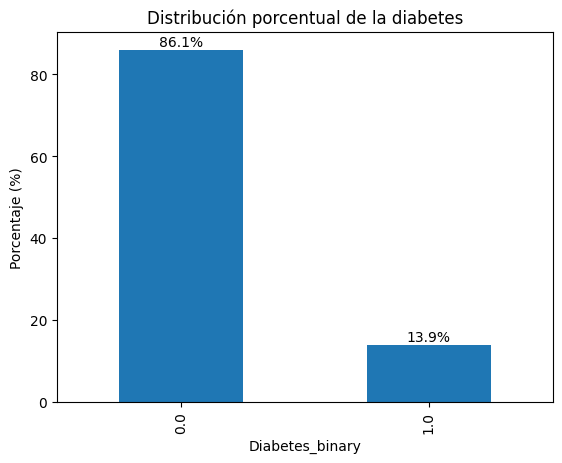

In [7]:
porcentajes = df_datos["Diabetes_binary"].value_counts(normalize=True) * 100
ax = porcentajes.plot(kind="bar")
ax.set_title("Distribución porcentual de la diabetes")
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Diabetes_binary")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

Se observa que esta variable está desbalanceada, hay más casos negativos los cuales son el 86.1% de los datos mientras que los positivos representan el 13.9% de los datos.

### 2.2. Variables predictoras

Se va a crear una función para mostrar las variables predictores en grupos de 4 variables, esta función va a ser genérica con el fin de poder ser reutilizada y no repetir mucho código:

In [22]:
def graficar_distribuciones(df, variables, titulo):
    
    fig, axes = plt.subplots(1, len(variables), figsize=(4 * len(variables), 4))

    if len(variables) == 1:
        axes = [axes]

    for ax, variable in zip(axes, variables):
        if df[variable].nunique() <= 15:
            porcentajes = (df[variable].value_counts(normalize=True).sort_index() * 100)
            bars = ax.bar(porcentajes.index.astype(str), porcentajes.values)
            ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=11, fontweight="bold")
            ax.set_ylim(0, max(porcentajes.values) * 1.18)
            ax.set_ylabel("Porcentaje (%)")

        else:
            ax.hist(df[variable].dropna(), bins=20)
            ax.set_ylabel("Frecuencia")

        ax.set_title(variable, fontsize=13, fontweight="bold")
        ax.set_xlabel("")

    fig.suptitle(titulo, fontsize=17, fontweight="bold")

    plt.tight_layout()
    plt.show()

Se van a dividir en 6 grupos diferentes de la siguiente manera:

#### 2.2.1. Condiciones cardiovasculares y metabólicas

Este grupo es particularmente importante porque reúne antecedentes y condiciones cardiovasculares que pueden estar asociados con un mayor riesgo metabólico y de diabetes:

* **HighBP:** Presión arterial alta: indica si la persona presenta hipertensión o presión arterial elevada. 0 = No y 1 = Sí.
* **HighChol:** Colesterol alto: indica si la persona presenta niveles elevados de colesterol. 0 = No y 1 = Sí.
* **Stroke:** Accidente cerebrovascular: indica si la persona ha sufrido alguna vez un accidente cerebrovascular. 0 = No y 1 = Sí.
* **HeartDiseaseorAttack:** Enfermedad cardíaca o infarto: indica antecedentes de enfermedad coronaria o infarto de miocardio. 0 = No y 1 = Sí.



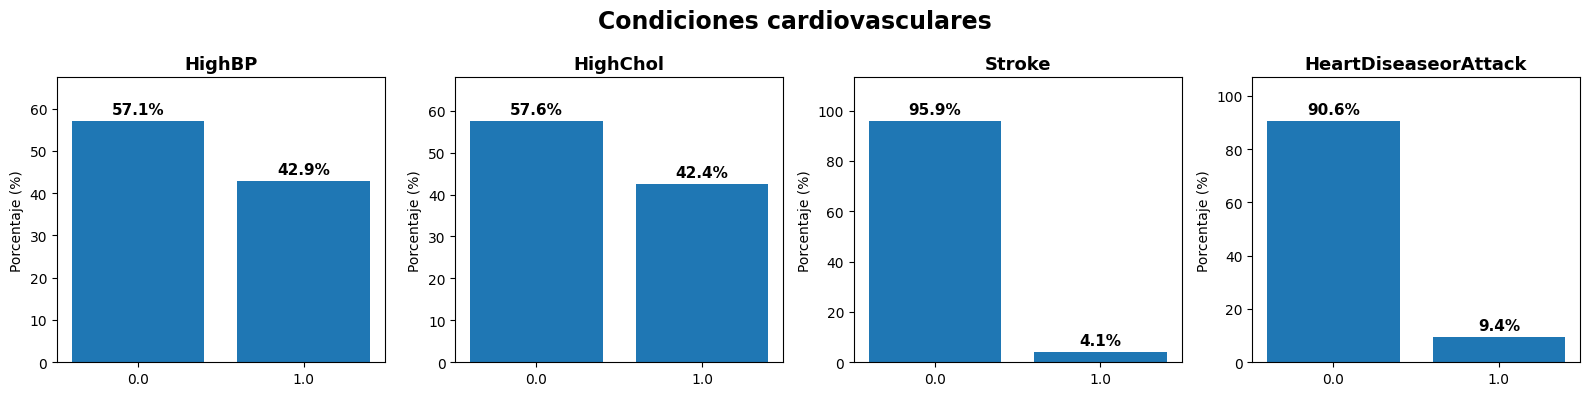

In [23]:
graficar_distribuciones(df_datos, ["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack"], "Condiciones cardiovasculares")

#### 2.2.2. Hábitos y estilos de vida

Estas variables permiten caracterizar algunos de los principales hábitos de vida de la población estudiada:

* **Smoker:** indica si la persona ha fumado al menos 100 cigarrillos durante toda su vida. 0 = No y 1 = Sí.
* **PhysActivity:** actividad física: indica si realizó actividad física o ejercicio durante los últimos 30 días, sin considerar la actividad laboral. 0 = No y 1 = Sí.
* **HvyAlcoholConsump:** identifica personas cuyo consumo de alcohol se clasifica como elevado según los criterios (hombres adultos >= 14 bebidas por semana y mujeres adultas >= 7 bebidas por semana). 0 = No y 1 = Sí.
* **Fruits:** indica si la persona consume frutas una o más veces al día. 0 = No y 1 = Sí.

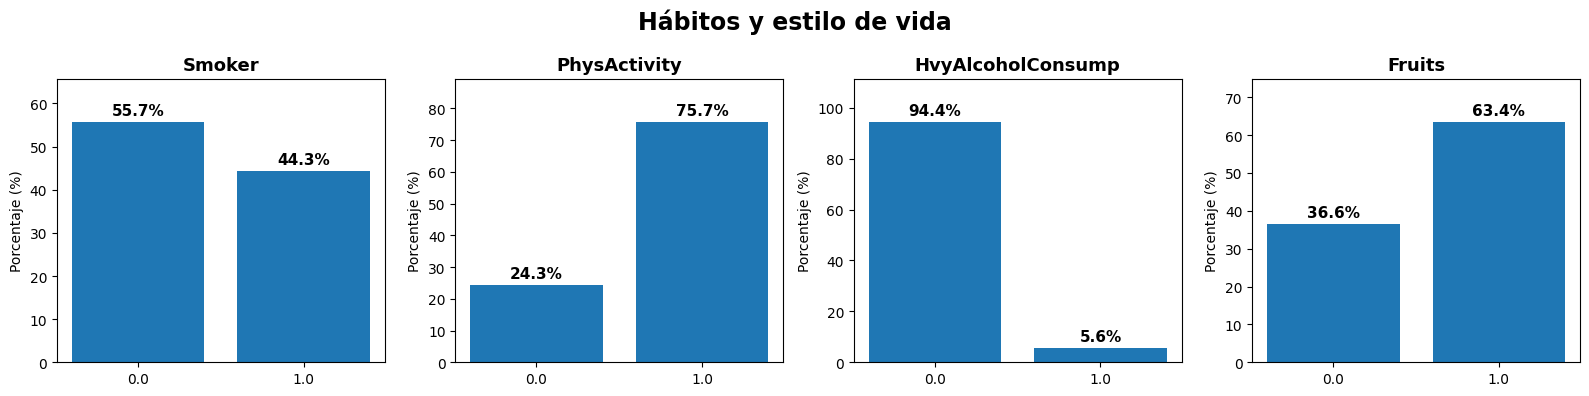

In [24]:
graficar_distribuciones(df_datos, ["Smoker", "PhysActivity", "HvyAlcoholConsump", "Fruits"], "Hábitos y estilo de vida")

#### 2.2.3. Vegetales y acceso a salud

Este bloque ayuda a distinguir factores relacionados con vegetales y acceso al sistema de salud.

* **Veggies:** indica si la persona consume vegetales una o más veces al día. 0 = No y 1 = Sí.
* **CholCheck:** indica si la persona se realizó una medición de colesterol durante los últimos 5 años. 0 = No y 1 = Sí.
* **AnyHealthcare:** indica si la persona cuenta con algún tipo de cobertura o seguro de salud. 0 = No y 1 = Sí.
* **NoDocbcCost:** No acudió al médico por costo: indica si, durante los últimos 12 meses, la persona necesitó consultar a un médico pero no pudo hacerlo debido al costo. 0 = No y 1 = Sí.

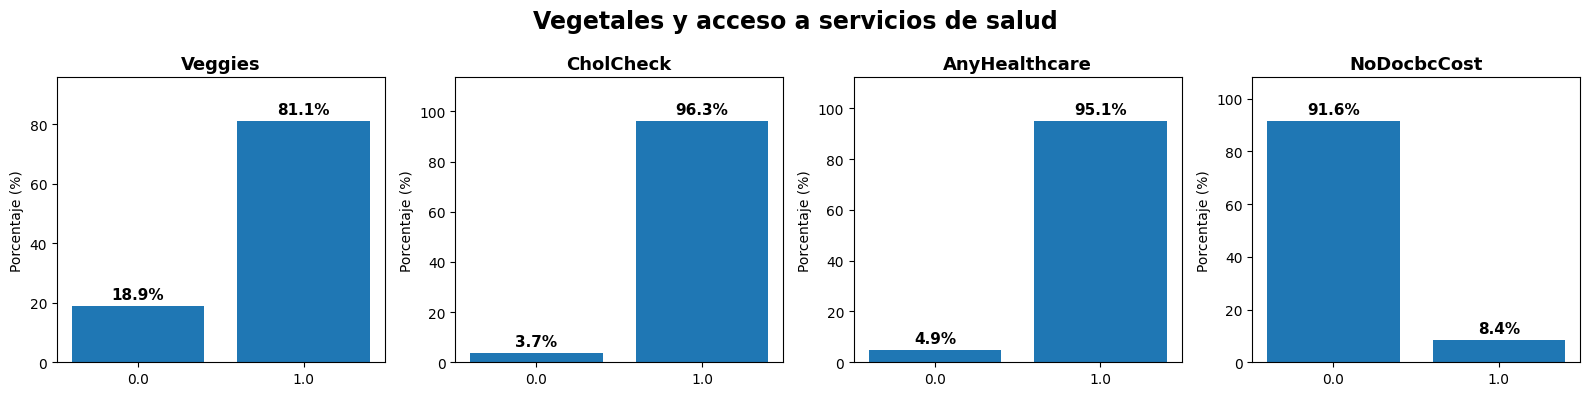

In [25]:
graficar_distribuciones(df_datos, ["Veggies", "CholCheck", "AnyHealthcare", "NoDocbcCost"], "Vegetales y acceso a servicios de salud")

#### 2.2.4. Estado físico del paciente

Este grupo permite analizar tanto medidas físicas y limitaciones físicas.

* **BMI** Mide el índice de Masa Corporal que es una medida que relaciona el peso y la altura de una persona. Es una variable cuantitativa y permite analizar la distribución del peso corporal en la población.
* **GenHlth** El estado general de salud representa la percepción que tiene la persona sobre su estado general de salud. Es una variable ordinal, donde normalmente los valores van desde una percepción excelente (=1) hasta una mala (=5).
* **PhysHlth** representa el número de días durante los últimos 30 días en los que la persona consideró que su salud física no fue buena.
* **DiffWalk** La dificultad para caminar indica si la persona presenta dificultades serias para caminar o subir escaleras. 0 = No y 1 = Sí.

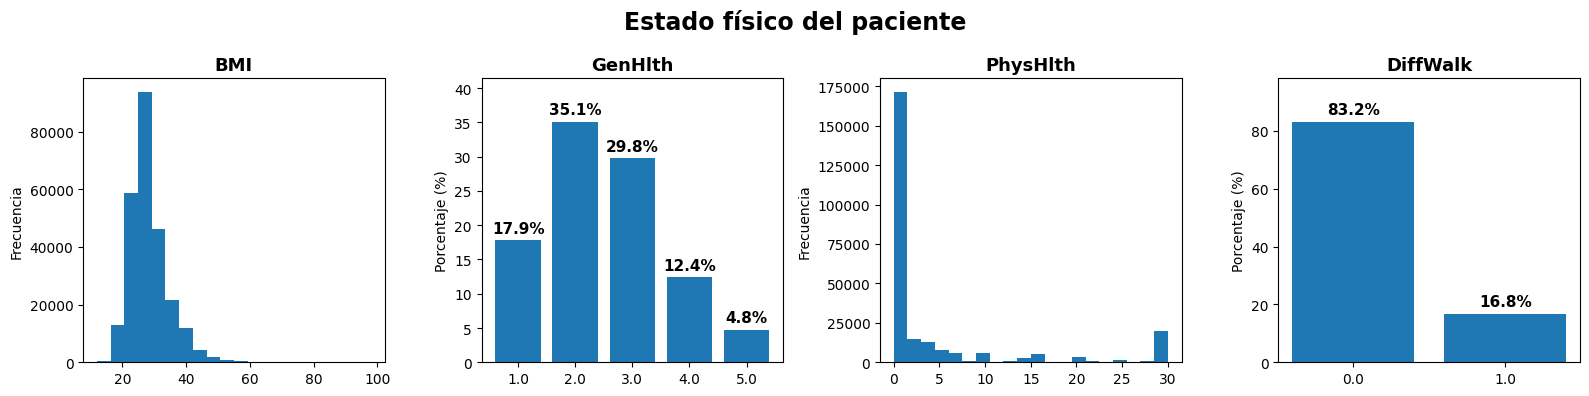

In [26]:
graficar_distribuciones(df_datos, ["BMI", "GenHlth", "PhysHlth", "DiffWalk"], "Estado físico del paciente")

#### 2.2.5. Salud mental y caracteristicas demográficas

Este grupo permite analizar la salud mental y algunas características demográficas de las personas analizadas:

* **MentHlth:** La salud mental corresponde al número de días, durante los últimos 30 días, en los que la persona consideró que su salud mental no fue buena.
* **Sex:** variable binaria utilizada para identificar el sexo reportado por la persona. 0 es mujer y 1 es hombre.
* **Age:** representa la edad mediante categorías o rangos de edad de la forma:<br/>
    - 1=Age 18-24
    - 2=Age 25-29
    - 3=Age 30-34
    - 4=Age 35-39
    - 5=Age 40-44
    - 6=Age 45-49
    - 7=Age 50-54
    - 8=Age 55-59
    - 9=Age 60-64
    - 10=Age 65-69
    - 11=Age 70-74
    - 12=Age 75-79
    - 13=Age 80-older
* **Education:** El nivel educativo es una variable ordinal que representa diferentes niveles de escolaridad alcanzados por la persona, como sigue: <br/>
    - 1: Nunca atendió al colegio o solamente jardín
    - 2: Grados de 1ero a 8vo
    - 3: Grados de 9no a 11
    - 4: Grados de 12 or graduado del colegio
    - 5: Universidad de 1 año a 3 años o una técnica
    - 6: Universidad de 4 años o más

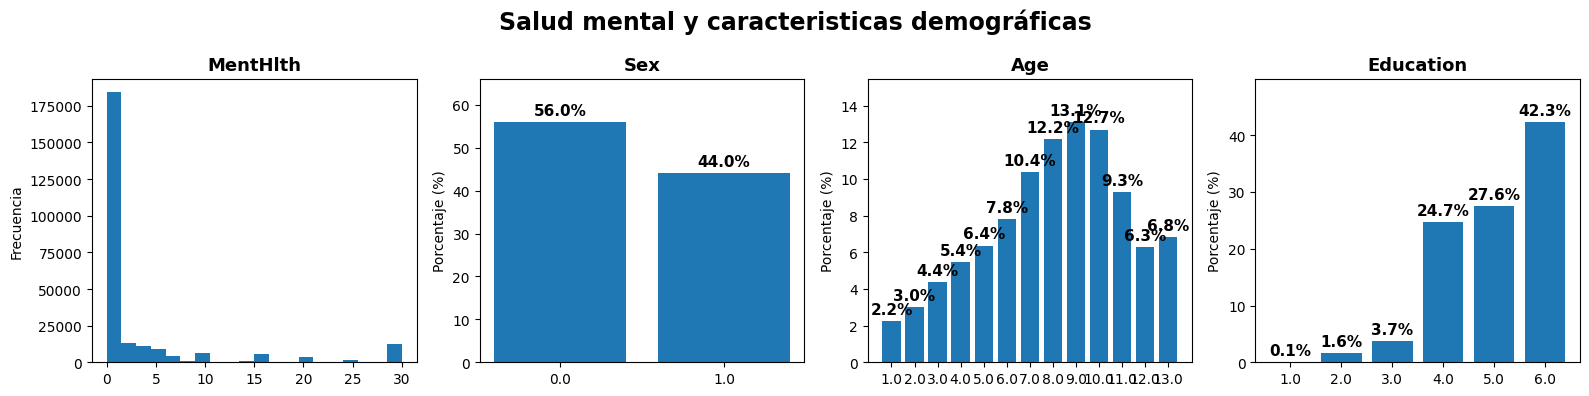

In [27]:
graficar_distribuciones(df_datos, ["MentHlth", "Sex", "Age", "Education"], "Salud mental y caracteristicas demográficas")

#### 2.2.6. Condición socioeconómica

* **Income:** el nivel de ingresos es una variable ordinal que clasifica a las personas según rangos de ingreso. Cada valor corresponde a USD:
  - 1: Menos que $10,000
  - 2: $10,000 a menos que $15,000
  - 3: $15,000 a menos que $20,000
  - 4: $20,000 a menos que $25,000
  - 5: Menos que $35,000 ($25,000 a menos que $35,000)
  - 6: Menos que $50,000 ($35,000 a menos que $50,000)
  - 7: Menos que $75,000 ($50,000 a menos que $75,000)
  - 8: $75,000 o más

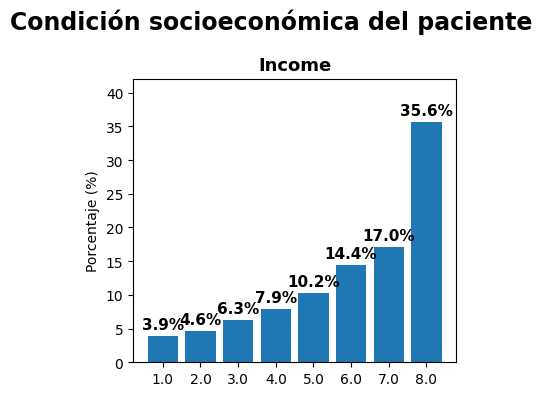

In [28]:
graficar_distribuciones(df_datos, ["Income"], "Condición socioeconómica del paciente")

## 3. Análisis de correlación

Se realiza un análisis de correlación entre las variables, la idea con esto es evitar en un futuro, cuando se haga un modelo, tratar de evitar la multicolinealidad.

In [29]:
variables = [
    'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
    'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
    'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
    'Income'
]

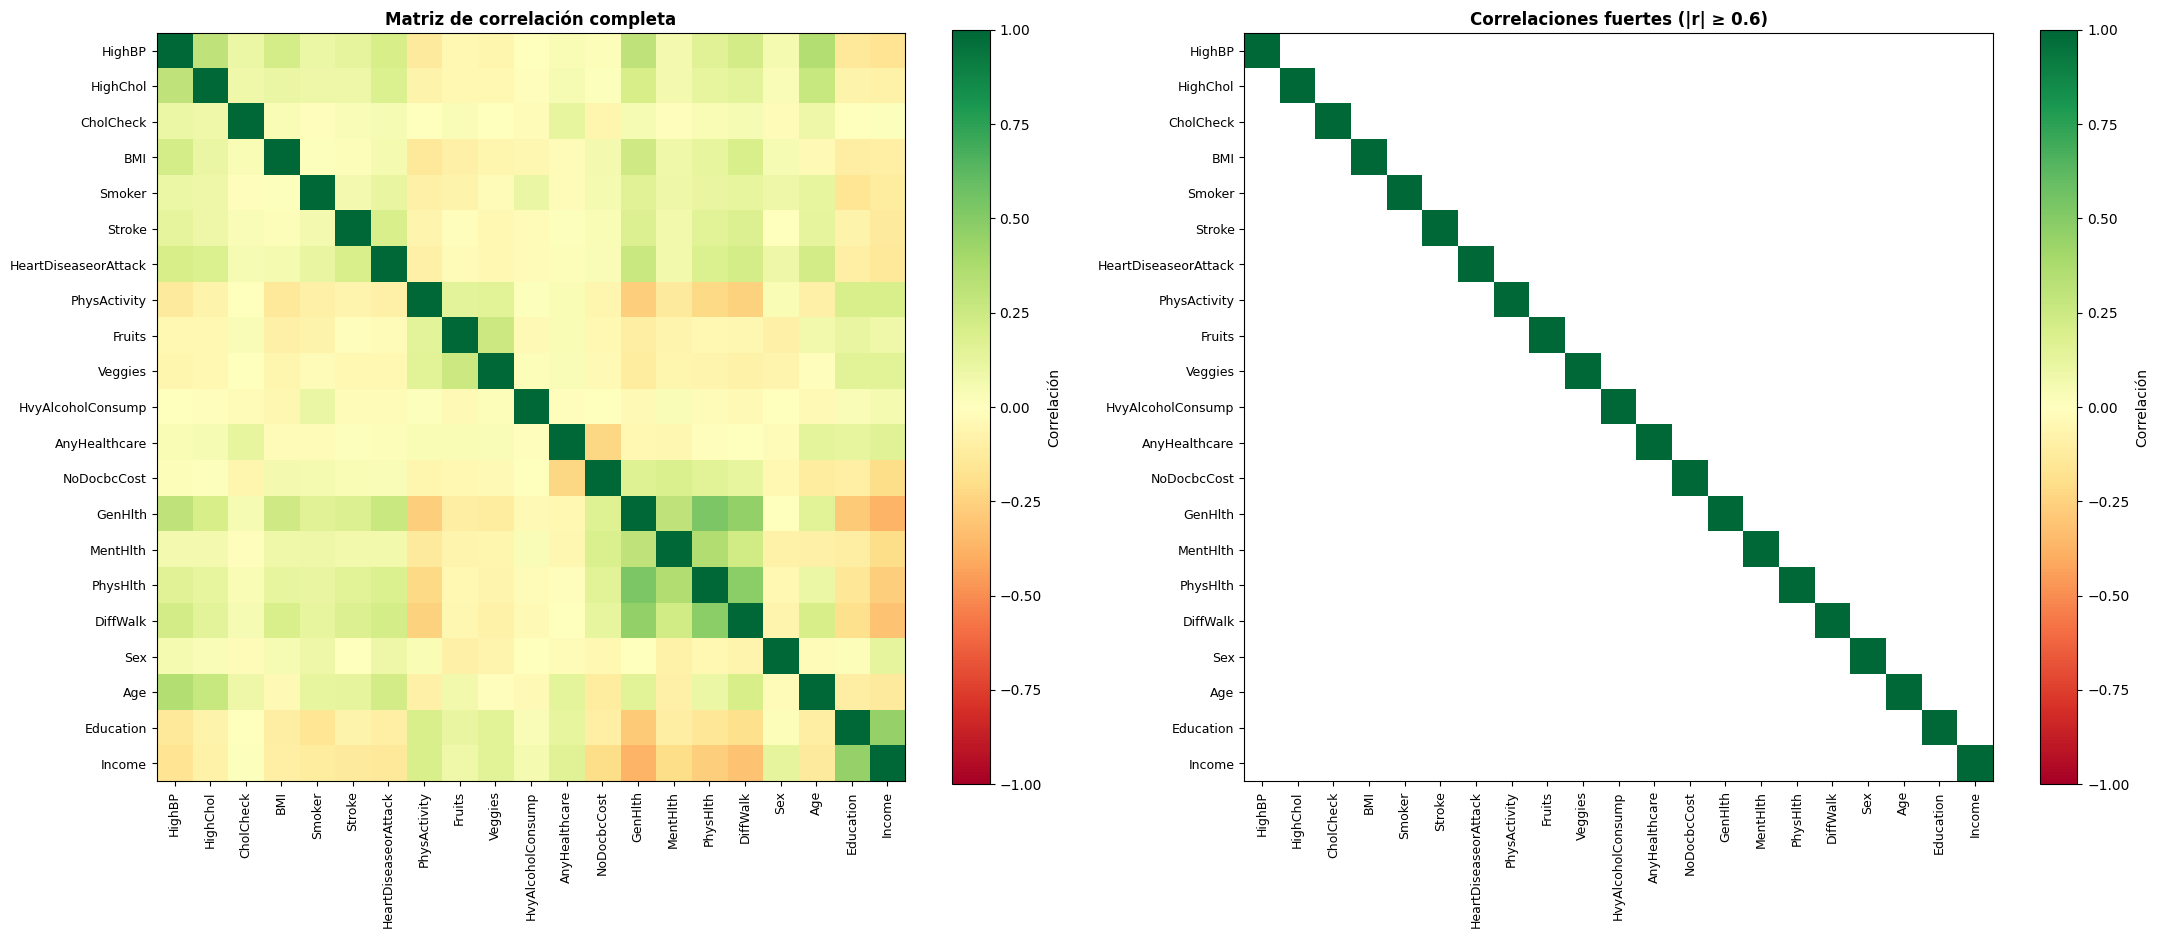

In [30]:
corr = df_datos[variables].corr()
corr_filtrada = corr.where(corr.abs() >= 0.6)

fig, ax = plt.subplots(1, 2, figsize=(22, 9))

for i, matriz in enumerate([corr, corr_filtrada]):
    im = ax[i].imshow(matriz, cmap="RdYlGn", vmin=-1, vmax=1)
    ax[i].set_xticks(range(len(variables)))
    ax[i].set_yticks(range(len(variables)))
    ax[i].set_xticklabels(variables, rotation=90, fontsize=9)
    ax[i].set_yticklabels(variables, fontsize=9)
    fig.colorbar(im, ax=ax[i], label="Correlación")

ax[0].set_title("Matriz de correlación completa", fontweight="bold")
ax[1].set_title("Correlaciones fuertes (|r| ≥ 0.6)", fontweight="bold")

plt.tight_layout()
plt.show()

No hay variables que estén muy correlacionadas linealmente.

## 4. Distribución de diabetes según variables explicativas

Se divide entre variables categóricas y las variables continuas:

### 4.1. Variables categóricas

La idea es mostrar qué porcentaje de cada valor categórico son personas con diabetes y sin diabetes:

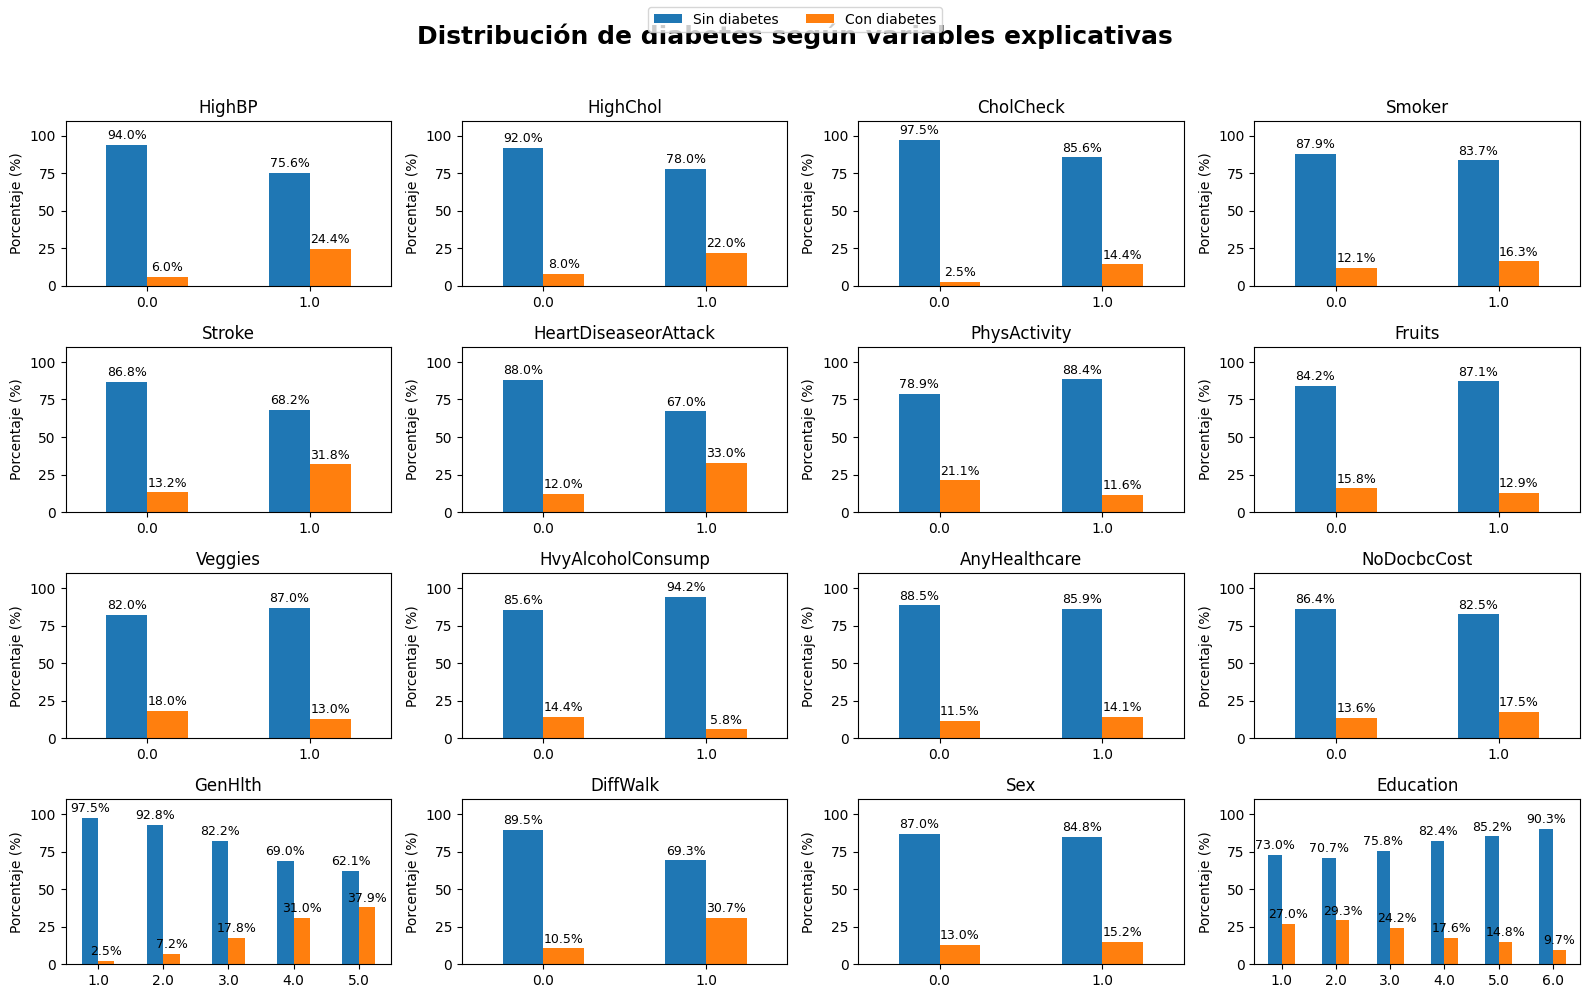

In [31]:
objetivo = "Diabetes_binary"

variables_cat = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
                 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
                 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
                 'DiffWalk', 'Sex', 'Education']

fig, axes = plt.subplots(4, 4, figsize=(16, 10))

for ax, variable in zip(axes.flat, variables_cat):
    tabla = pd.crosstab(df_datos[variable], df_datos[objetivo], normalize="index") * 100
    tabla.plot(kind="bar", ax=ax, legend=False)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=9, padding=2)

    ax.set(title=variable, xlabel="", ylabel="Porcentaje (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, 110)

fig.legend(["Sin diabetes", "Con diabetes"], loc="upper center", ncol=2)
fig.suptitle("Distribución de diabetes según variables explicativas", fontsize=18, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

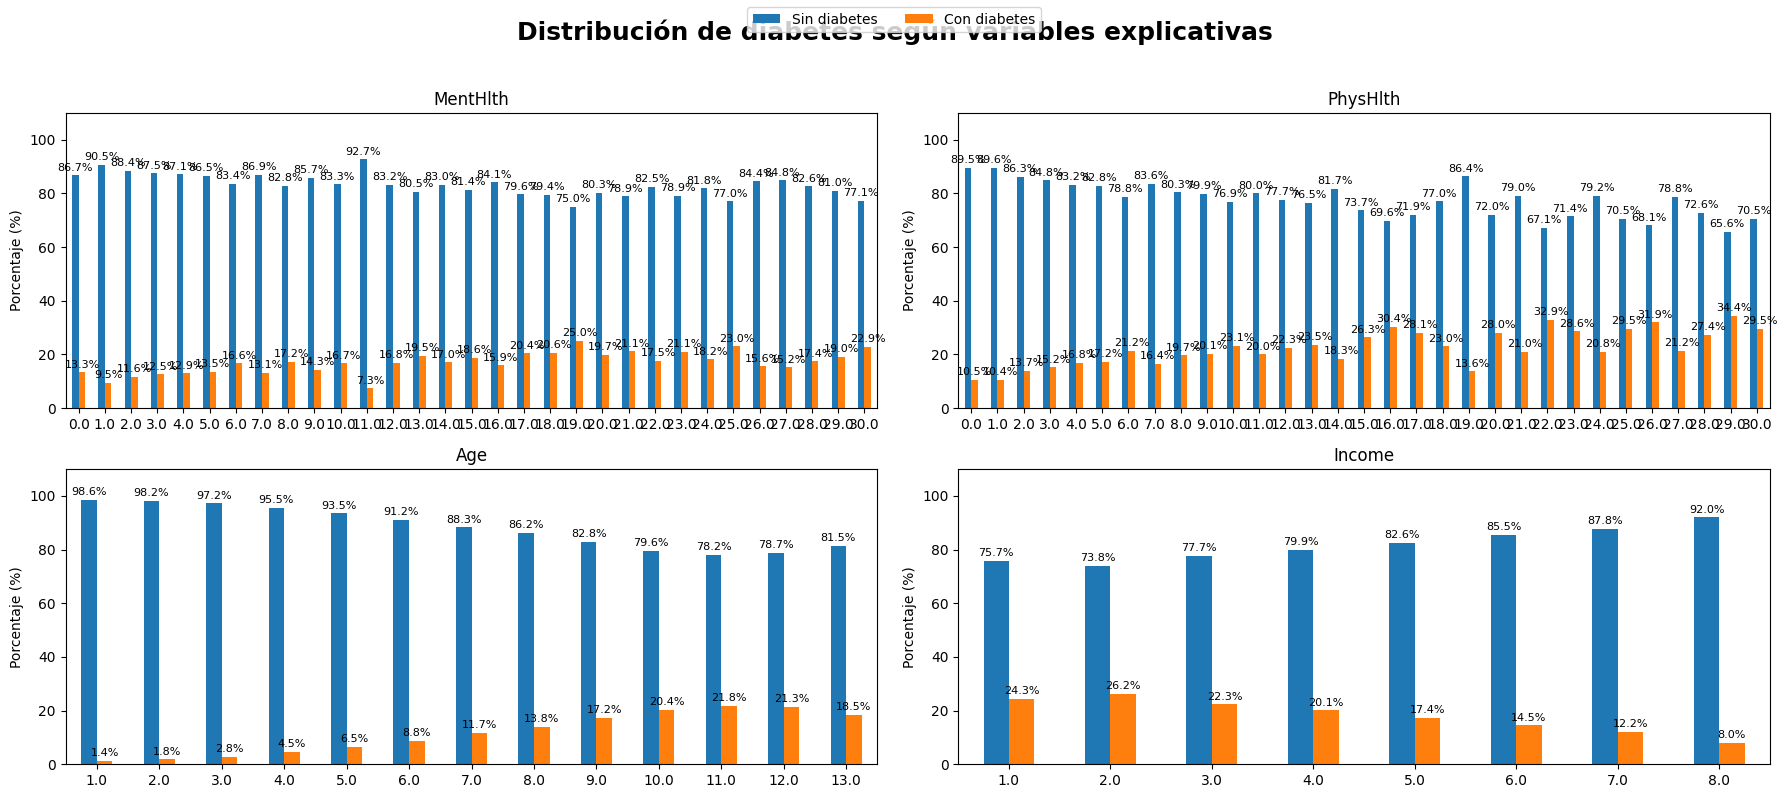

In [32]:
variables_cat = ['MentHlth', 'PhysHlth', 'Age', 'Income']

fig, axes = plt.subplots(2, 2, figsize=(18, 8))

for ax, variable in zip(axes.flat, variables_cat):
    tabla = pd.crosstab(df_datos[variable], df_datos[objetivo], normalize="index") * 100
    tabla.plot(kind="bar", ax=ax, legend=False)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=2)

    ax.set(title=variable, xlabel="", ylabel="Porcentaje (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, 110)

fig.legend(["Sin diabetes", "Con diabetes"], loc="upper center", ncol=2)
fig.suptitle("Distribución de diabetes según variables explicativas", fontsize=18, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 4.2. Variable continua

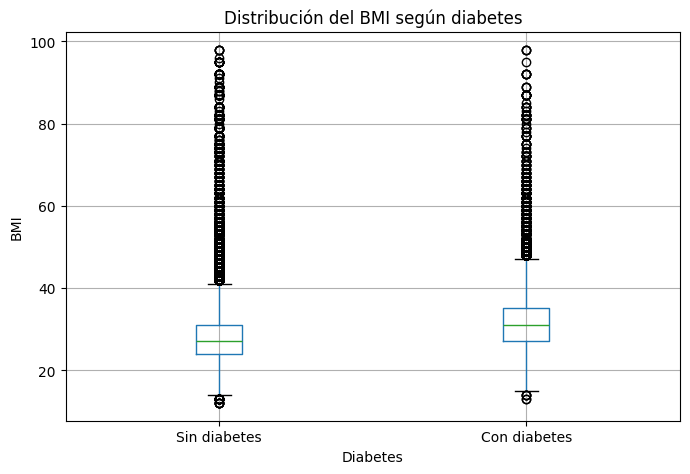

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))

df_datos.boxplot(column="BMI", by=objetivo, ax=ax)

ax.set(title="Distribución del BMI según diabetes", xlabel="Diabetes", ylabel="BMI")
ax.set_xticklabels(["Sin diabetes", "Con diabetes"])

plt.suptitle("")
plt.tight_layout()
plt.show()

## 5. Correlación de las variables con la variable independiente

In [35]:
corr_diabetes = (df_datos[variables + [objetivo]].corr()[objetivo].drop(objetivo).sort_values(key=abs, ascending=False))

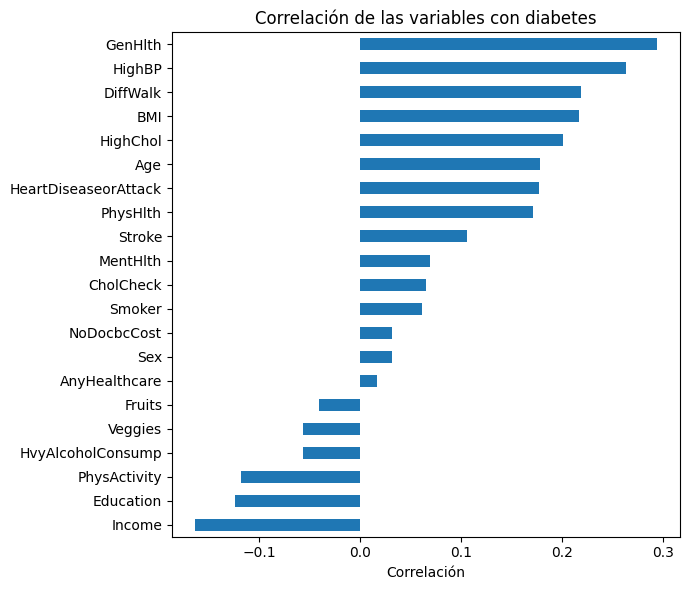

In [37]:
corr_diabetes.sort_values().plot(kind="barh",figsize=(7, 6))
plt.title("Correlación de las variables con diabetes")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()